# Progressive DP-Based DTW Shape Alignment & Visualization

This notebook demonstrates and visualizes our **Progressive DP-based DTW (Dynamic Time Warping)** shape-matching algorithm.

We will evaluate two key real-world geospatial scenarios:
1. **Scenario 1 (Nested Overlap)**: Matching a shorter trajectory (**Source Segment A**) that is fully nested within a longer road (**Destination Segment B**).
2. **Scenario 2 (Non-Nested Partial Overlap)**: Matching two roads that partially overlap, but neither segment is fully contained within the other.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

# Ensure our local network_matching library is in the Python path
sys.path.append(os.path.abspath(".."))
from network_matching import dtw_align

print("Libraries imported successfully!")

Libraries imported successfully!


## Scenario 1: Nested Overlap (Shorter Source Trajectory on Longer Destination Road)

In this scenario:
* **Source Segment A (Trajectory)** is the shorter segment ($X \in [20, 80]$).
* **Destination Segment B (Road)** is the longer segment ($X \in [0, 100]$), shifted slightly upward by 6 units.

Since Destination B extends before and after Source A, the match starts at the beginning of Source A projected onto Destination B ($X = 20$), yielding a perfect $100\%$ overlap for the Source trajectory.

In [2]:
# Generate Source Segment A (Trajectory: shorter curved road, spanning X=20 to X=80)
x_a = np.linspace(20, 80, 13)
y_a = 15.0 * np.sin(x_a / 20.0)
coords_a = list(zip(x_a, y_a))

# Generate Destination Segment B (Road: longer curved road, spanning X=0 to X=100, shifted by 6m)
x_b = np.linspace(0, 100, 20)
y_b = (15.0 * np.sin(x_b / 20.0)) + 6.0
coords_b = list(zip(x_b, y_b))

print(f"Source Segment A (Trajectory) has {len(coords_a)} nodes (length: ~60m).")
print(f"Destination Segment B (Road) has {len(coords_b)} nodes (length: ~100m).")

Source Segment A (Trajectory) has 13 nodes (length: ~60m).
Destination Segment B (Road) has 20 nodes (length: ~100m).


In [3]:
# Run the progressive DTW alignment
dtw_dist, warping_path, dtw_metrics = dtw_align(coords_a, coords_b)

print(f"Average DTW Alignment Distance: {dtw_dist:.2f} meters")
print(f"Maximum Alignment Drift (Max): {dtw_metrics['max']:.2f} meters")
print(f"Minimum Alignment Distance (Min): {dtw_metrics['min']:.2f} meters")
print(f"Warping Path Steps: {len(warping_path)} steps")
print(f"Source Overlap Percentage: {dtw_metrics['overlap_pct']:.2f}%")

Average DTW Alignment Distance: 5.35 meters
Maximum Alignment Drift (Max): 6.10 meters
Minimum Alignment Distance (Min): 4.80 meters
Warping Path Steps: 25 steps
Source Overlap Percentage: 100.00%


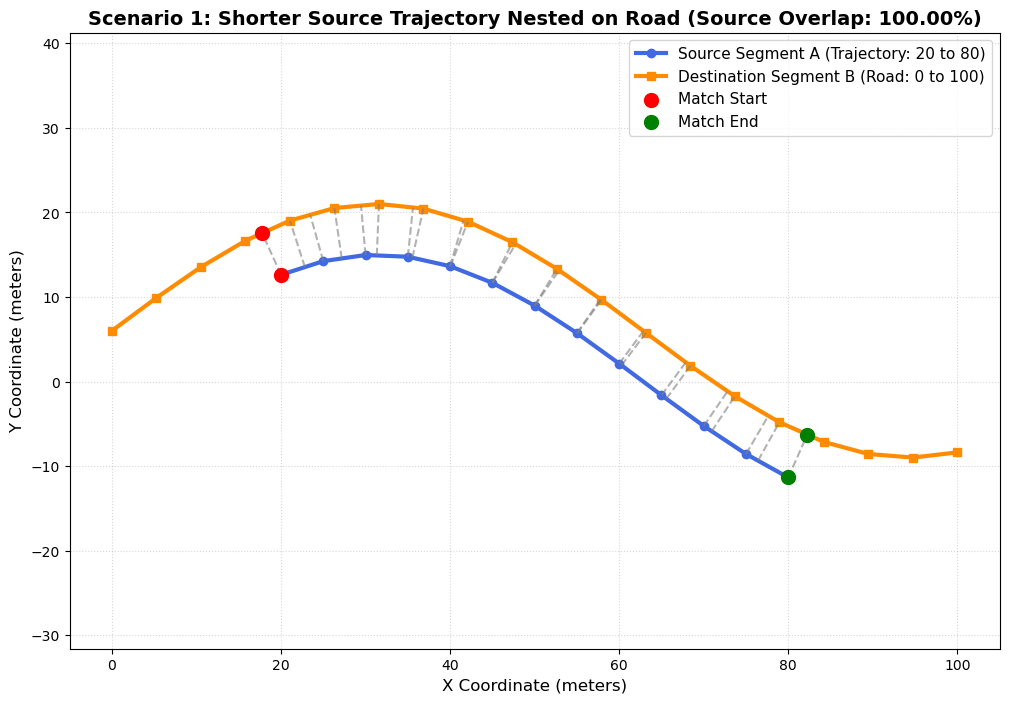

In [4]:
plt.figure(figsize=(12, 8))

# Plot segments
x_vals_a, y_vals_a = zip(*coords_a)
x_vals_b, y_vals_b = zip(*coords_b)
plt.plot(x_vals_a, y_vals_a, label="Source Segment A (Trajectory: 20 to 80)", color="royalblue", linewidth=3, marker='o', markersize=6)
plt.plot(x_vals_b, y_vals_b, label="Destination Segment B (Road: 0 to 100)", color="darkorange", linewidth=3, marker='s', markersize=6)

# Draw warping path alignment links
for idx, (pt_a, pt_b) in enumerate(warping_path):
    plt.plot([pt_a[0], pt_b[0]], [pt_a[1], pt_b[1]], color="gray", linestyle="--", alpha=0.6)
    if idx == 0:
        plt.scatter([pt_a[0], pt_b[0]], [pt_a[1], pt_b[1]], color="red", zorder=5, s=100, label="Match Start")
    elif idx == len(warping_path) - 1:
        plt.scatter([pt_a[0], pt_b[0]], [pt_a[1], pt_b[1]], color="green", zorder=5, s=100, label="Match End")

plt.title(f"Scenario 1: Shorter Source Trajectory Nested on Road (Source Overlap: {dtw_metrics['overlap_pct']:.2f}%)", fontsize=14, fontweight='bold')
plt.xlabel("X Coordinate (meters)", fontsize=12)
plt.ylabel("Y Coordinate (meters)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(fontsize=11, loc="best")
plt.axis("equal")
plt.show()

## Scenario 2: Non-Nested Partial Overlap (Neither Segment is fully contained)

In this second scenario, we test the algorithm on two roads that partially overlap, but **neither is a subset of the other**:
* **Source Segment A2**: Spans from $X = 30$ to $X = 100$ (length: ~70m).
* **Destination Segment B2**: Spans from $X = 0$ to $X = 70$, shifted by 6 units.

Since B2 starts at $X=0$ and A2 starts at $X=30$, B2 has an unmatched beginning tail. Since A2 ends at $X=100$ and B2 ends at $X=70$, A2 has an unmatched ending tail.
The overlap region is exactly $X \in [30, 70]$. Our algorithm dynamically finds the start of the overlap ($X = 30$) and matches both segments perfectly, stopping when B2 is completed and leaving A2's trailing end unmatched (yielding ~57% overlap on Source A2).

In [5]:
# Generate Source Segment A2 (spanning X=30 to X=100)
x_a2 = np.linspace(30, 100, 15)
y_a2 = 15.0 * np.sin(x_a2 / 20.0)
coords_a2 = list(zip(x_a2, y_a2))

# Generate Destination Segment B2 (Road: spanning X=0 to X=70, shifted by 6m)
x_b2 = np.linspace(0, 70, 15)
y_b2 = (15.0 * np.sin(x_b2 / 20.0)) + 6.0
coords_b2 = list(zip(x_b2, y_b2))

print(f"Source Segment A2 spans from X={coords_a2[0][0]:.1f} to X={coords_a2[-1][0]:.1f} ({len(coords_a2)} nodes).")
print(f"Destination Segment B2 spans from X={coords_b2[0][0]:.1f} to X={coords_b2[-1][0]:.1f} ({len(coords_b2)} nodes).")

Source Segment A2 spans from X=30.0 to X=100.0 (15 nodes).
Destination Segment B2 spans from X=0.0 to X=70.0 (15 nodes).


In [6]:
# Run the progressive DTW alignment
dtw_dist2, warping_path2, dtw_metrics2 = dtw_align(coords_a2, coords_b2)

print(f"Average DTW Alignment Distance: {dtw_dist2:.2f} meters")
print(f"Maximum Alignment Drift (Max): {dtw_metrics2['max']:.2f} meters")
print(f"Minimum Alignment Distance (Min): {dtw_metrics2['min']:.2f} meters")
print(f"Warping Path Steps: {len(warping_path2)} steps")
print(f"Source Overlap Percentage: {dtw_metrics2['overlap_pct']:.2f}%")

Average DTW Alignment Distance: 5.32 meters
Maximum Alignment Drift (Max): 6.00 meters
Minimum Alignment Distance (Min): 4.80 meters
Warping Path Steps: 17 steps
Source Overlap Percentage: 54.07%


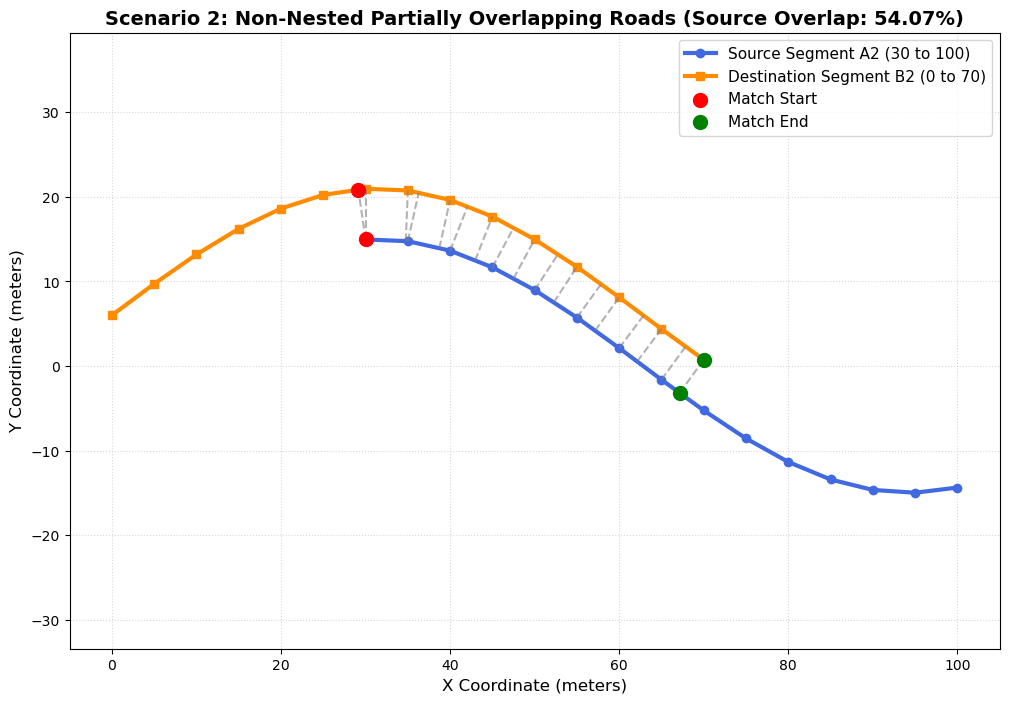

In [7]:
plt.figure(figsize=(12, 8))

# Plot segments
x_vals_a2, y_vals_a2 = zip(*coords_a2)
x_vals_b2, y_vals_b2 = zip(*coords_b2)
plt.plot(x_vals_a2, y_vals_a2, label="Source Segment A2 (30 to 100)", color="royalblue", linewidth=3, marker='o', markersize=6)
plt.plot(x_vals_b2, y_vals_b2, label="Destination Segment B2 (0 to 70)", color="darkorange", linewidth=3, marker='s', markersize=6)

# Draw warping path alignment links
for idx, (pt_a, pt_b) in enumerate(warping_path2):
    plt.plot([pt_a[0], pt_b[0]], [pt_a[1], pt_b[1]], color="gray", linestyle="--", alpha=0.6)
    if idx == 0:
        plt.scatter([pt_a[0], pt_b[0]], [pt_a[1], pt_b[1]], color="red", zorder=5, s=100, label="Match Start")
    elif idx == len(warping_path2) - 1:
        plt.scatter([pt_a[0], pt_b[0]], [pt_a[1], pt_b[1]], color="green", zorder=5, s=100, label="Match End")

plt.title(f"Scenario 2: Non-Nested Partially Overlapping Roads (Source Overlap: {dtw_metrics2['overlap_pct']:.2f}%)", fontsize=14, fontweight='bold')
plt.xlabel("X Coordinate (meters)", fontsize=12)
plt.ylabel("Y Coordinate (meters)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(fontsize=11, loc="best")
plt.axis("equal")
plt.show()